Objective:
Analyse historical gold prices and predict short-term trends

In [211]:
import sys
print(sys.executable)

/opt/anaconda3/bin/python


['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Adj Close', 'Daily_Return', 'MA_20', 'MA_50', 'MA_200', 'Volatility_20', 'Year', 'Month', 'Day_of_Week', 'Quarter']
2511
Year 2016.0: Lowest price = 106.26
Year 2016.0: Highest price = 131.15
Year 2017.0: Lowest price = 109.37
Year 2017.0: Highest price = 128.32
Year 2018.0: Lowest price = 111.06
Year 2018.0: Highest price = 129.51
Year 2019.0: Lowest price = 119.54
Year 2019.0: Highest price = 146.82
Year 2020.0: Lowest price = 136.12
Year 2020.0: Highest price = 194.45
Year 2021.0: Lowest price = 157.13
Year 2021.0: Highest price = 183.21
Year 2022.0: Lowest price = 150.57
Year 2022.0: Highest price = 193.30
Year 2023.0: Lowest price = 168.19
Year 2023.0: Highest price = 193.18
Year 2024.0: Lowest price = 183.78
Year 2024.0: Highest price = 257.71
Year 2025.0: Lowest price = 242.05
Year 2025.0: Highest price = 418.45
Year 2026.0: Lowest price = 396.25
Year 2026.0: Highest price = 458.75
The average low is 172.40 and the average high

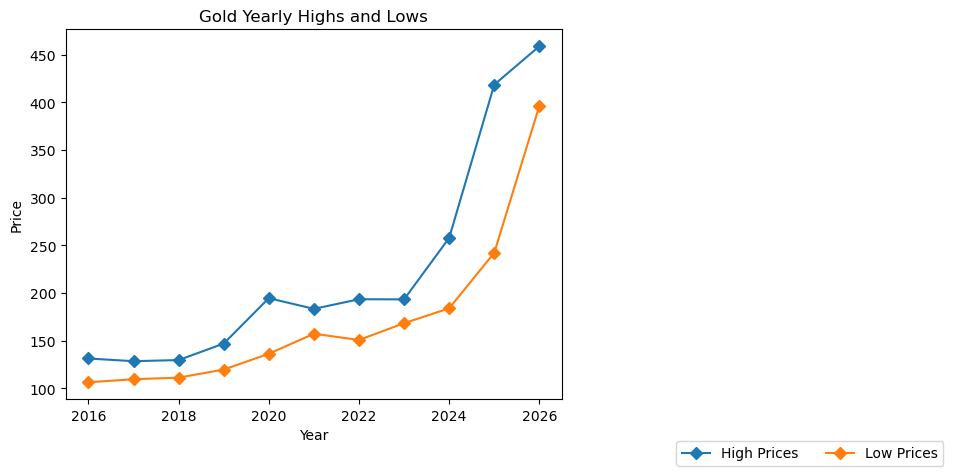

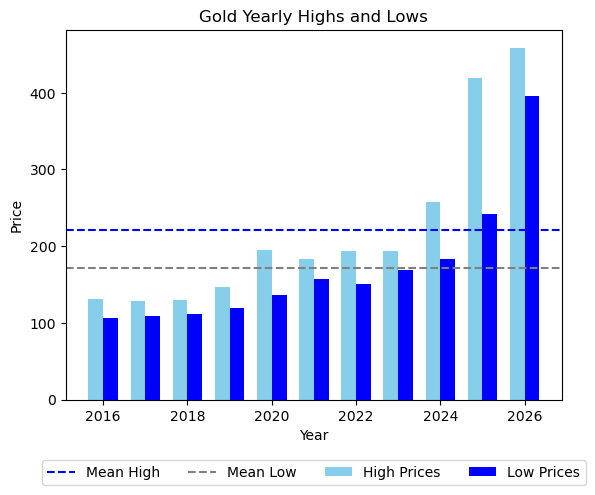

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/johnd/Desktop/portfolio/Data Analytics/gold_prices_10y.csv")

print(list(df.columns))
length = print(len(df))

df.head()

#Have to convert to datetime form so Python reads as date not string
df['Date']= pd.to_datetime(df['Date'])

#What was the highest and lowest prices of each year?
#Creating a class to assign the same method to multiple columns
class LowestHighestPrice:

    def __init__ (self, df, year_col='Year',  low_col='Low', high_col='High' ):
        self.df = df
        self.year_col = year_col
        self.low_col = low_col
        self.high_col = high_col
        
    #Dependency injection
    def df_ref(self):
        df_copy = self.df.copy()
        df_copy['Date'] = df_copy['Date'].dt.year
        self.df = df_copy


    def ann_low_high(self):
        low = self.df.groupby('Year')[[self.low_col, self.high_col]].agg(
            low=(self.low_col, 'min'), high=(self.high_col, 'max')).reset_index()
        for _, row in low.iterrows():
            print(f"Year {row['Year']}: Lowest price = {row['low']:.2f}")
            print(f"Year {row['Year']}: Highest price = {row['high']:.2f}")
        return low
   

    def sum_low_high(self):
        avg_low = self.df[self.low_col].mean()
        avg_high = self.df[self.high_col].mean()
        print(f"The average low is {avg_low:.2f} and the average high is {avg_high:.2f}")


lpy = LowestHighestPrice(df)
lpy.df_ref()
lpy.ann_low_high()
lpy.sum_low_high()

#Plotting line graph
years = [2016, 2017, 2018, 2019, 2020,2021, 2022, 2023, 2024, 2025, 2026 ]
highs = [ 131.15, 128.32, 129.51, 146.82, 194.45, 183.21, 193.30, 193.18, 257.71, 418.45, 458.75]
lows = [106.26, 109.37, 111.06, 119.54, 136.12, 157.13, 150.57, 168.19, 183.78, 242.05, 396.25]

plt.plot(years, highs, label='High Prices', marker='D')
plt.plot(years, lows, label='Low Prices', marker='D')
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Gold Yearly Highs and Lows')
plt.legend(loc='lower center', bbox_to_anchor=(1.5, -0.2), ncol=2)
plt.show()


#Plotting bar chart
years = [2016, 2017, 2018, 2019, 2020,2021, 2022, 2023, 2024, 2025, 2026 ]
highs = [ 131.15, 128.32, 129.51, 146.82, 194.45, 183.21, 193.30, 193.18, 257.71, 418.45, 458.75]
lows = [106.26, 109.37, 111.06, 119.54, 136.12, 157.13, 150.57, 168.19, 183.78, 242.05, 396.25]

width = 0.35 # width of the bars

# Create bars side by side
plt.bar([y - width/2 for y in years], highs, width=width, label='High Prices', color='skyblue')
plt.bar([y + width/2 for y in years], lows, width=width, label='Low Prices', color='blue')

# Add mean lines
plt.axhline(sum(highs)/len(highs), color='blue', linestyle='--', label='Mean High')
plt.axhline(sum(lows)/len(lows), color='gray', linestyle='--', label='Mean Low')

plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Gold Yearly Highs and Lows')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=4)
plt.show()






        

